## **Solving First-Order ODEs**

**Method 1.** The next code used Method 1, namely the custom loss enforces the differential equation to hold at certain colocation points. We train the network for 200 epochs and consider the initial condition weighted with w=10 for accuracy reasons.  

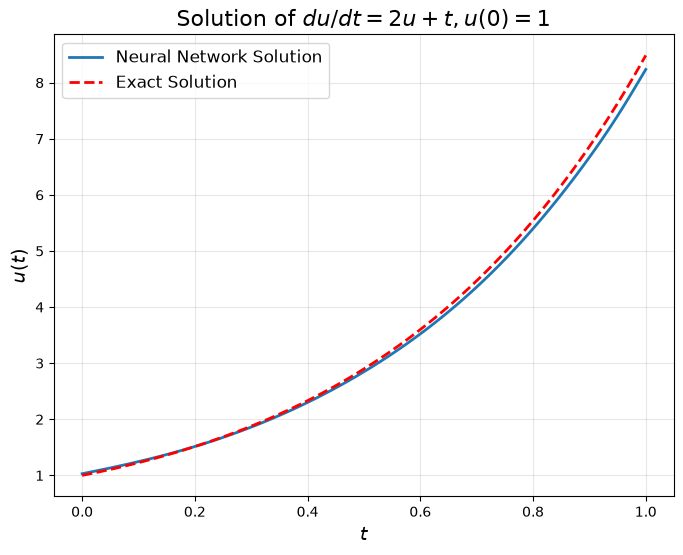

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define the exact solution for comparison
def exact_solution(t):
    return (5 * np.exp(2 * t) - 2 * t - 1) / 4

# Define the function F(u, t) = 2*u + t
def F(u, t):
    return 2 * u + t

# Neural network to approximate u(t)
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 50),   # Hidden layer with 50 neurons
            nn.Tanh(),
            nn.Linear(50, 50),  # Another hidden layer
            nn.Tanh(),
            nn.Linear(50, 1)    # Output layer
        )

    def forward(self, x):
        return self.model(x)

model = NeuralNetwork()

# Generate training data: time points in [0, 1]
t_train = np.linspace(0, 1, 100).reshape(-1, 1)
t_train = torch.tensor(t_train, dtype=torch.float32, requires_grad=True)

# Custom loss function
def custom_loss():
    t_input = t_train  # Training points
    u_pred = model(t_input)  # Predicted u(t)

    # Compute du/dt using automatic differentiation
    du_dt = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_input,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    # Boundary condition loss
    boundary_loss = (model(torch.tensor([[0.0]], dtype=torch.float32)) - 1.0) ** 2  # u(0) = 1

    # Equation loss
    equation_loss = torch.mean((du_dt - F(u_pred, t_input)) ** 2)

    # Total loss
    return 10 * boundary_loss + equation_loss

# Compile the model
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Dummy target, as the loss handles everything
dummy_target = torch.zeros_like(t_train)

# Train the model
epochs = 200

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = custom_loss()
    loss.backward()
    optimizer.step()

# Generate points for plotting
t_plot = np.linspace(0, 1, 100).reshape(-1, 1)
t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32)

with torch.no_grad():
    u_nn = model(t_plot_tensor).numpy()  # Neural network solution

u_exact = exact_solution(t_plot)  # Exact solution

# Plot the solutions
plt.figure(figsize=(8, 6))
plt.plot(t_plot, u_nn, label="Neural Network Solution", linewidth=2)
plt.plot(t_plot, u_exact, label="Exact Solution", linewidth=2, color='red', linestyle='dashed')
plt.title("Solution of $du/dt = 2u + t, u(0) = 1$", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel("$u(t)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

**Method 2.** The next code used Method 2, namely we use the trial solution $u(t) = u_0 + t NN(t, \theta)$. Even if we train the network for only 50 epochs we obtain better learning than in the case of the previous Method 1.  

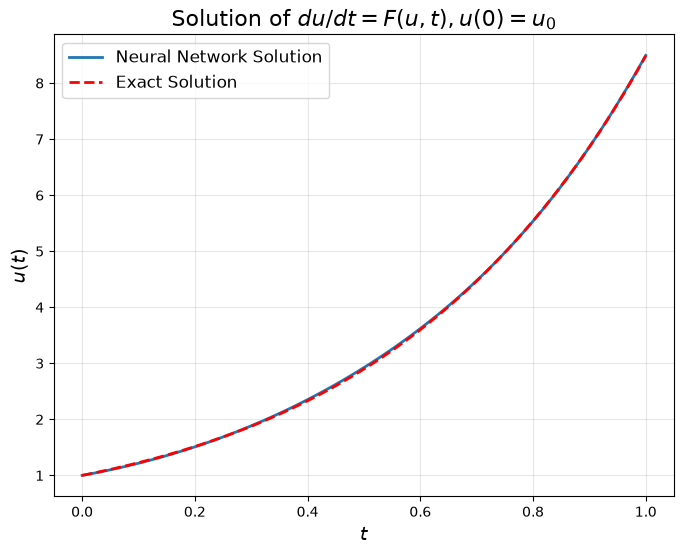

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define the function F(u, t) (adjustable to any problem)
def F(u, t):
    return 2 * u + t  # Example: Replace with any specific function

# Define the initial condition u(0) = u_0
u_0 = 1.0

# Neural network to approximate the correction term NN(theta, t)
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 50),  # Hidden layer with 50 neurons
            nn.Tanh(),
            nn.Linear(50, 50),  # Another hidden layer
            nn.Tanh(),
            nn.Linear(50, 1)    # Output layer
        )

    def forward(self, x):
        return self.network(x)

model = NeuralNet()

# Generate training data: time points in [0, 1]
t_train = torch.linspace(0, 1, 100).view(-1, 1)
dummy_target = torch.zeros_like(t_train)  # Dummy target, as the loss handles everything

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Custom loss function
def custom_loss():
    t_input = t_train.clone().detach().requires_grad_(True)  # Training points

    nn_t = model(t_input)  # NN(theta, t)

    # Compute u(t) = u_0 + t * NN(theta, t)
    u_t = u_0 + t_input * nn_t

    # Compute du/dt = NN(theta, t) + t * d(NN(theta, t))/dt
    d_nn_dt = torch.autograd.grad(
        outputs=nn_t,
        inputs=t_input,
        grad_outputs=torch.ones_like(nn_t),
        create_graph=True
    )[0]

    du_dt = nn_t + t_input * d_nn_dt

    # Residual of the ODE: du/dt - F(u, t)
    residual = du_dt - F(u_t, t_input)
    return torch.mean(residual ** 2)

# Train the model
epochs = 50

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = custom_loss()
    loss.backward()
    optimizer.step()

# Generate points for plotting
t_plot = torch.linspace(0, 1, 100).view(-1, 1)

with torch.no_grad():
    u_nn = u_0 + t_plot * model(t_plot)  # Neural network solution

# Convert to NumPy
t_plot_np = t_plot.numpy()
u_nn_np = u_nn.numpy()

# Example: Replace with exact solution for comparison if known
# Here, using a placeholder for comparison (replace with real function if available)
u_exact = (5 * np.exp(2 * t_plot_np) - 2 * t_plot_np - 1) / 4  # Example: Exact solution for F(u, t) = 2u + t

# Plot the solutions
plt.figure(figsize=(8, 6))
plt.plot(t_plot_np, u_nn_np, label="Neural Network Solution", linewidth=2)
plt.plot(t_plot_np, u_exact, label="Exact Solution", linewidth=2, color='red', linestyle='dashed')
plt.title("Solution of $du/dt = F(u, t), u(0) = u_0$", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel("$u(t)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()